In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import constants as const
from tqdm import tqdm

In [2]:
two_dim = False
inputname = 'runs/25_8/H_input_2025-08-25_19-58-32.txt'
outputname=inputname.replace('input', 'output')
logname=inputname.replace('input', 'log')
orbit_plot = True
input_plot = False #if True plots the initial distribution from the input
density_plot = False

In [3]:
def input_opening(inputname = ''):
    inputf = open(inputname, 'r')

    N = int(inputf.readline())
    n_dim = int(inputf.readline())
        
    t_0 = float(inputf.readline())

    mass_0 = []
    for i in range(3, N+3):
        mass_0.append(float(inputf.readline()))
        
    mass_0 = np.array(mass_0)
    
    #the initial positions are arranged in an array where the first index gives the particle 
    #and the second gives the direction
    position_0 = []
    for i in range(N+4, 2*N + 4):
        position_0.append((inputf.readline()).rstrip())
        
    position_0 = [p.split() for p in position_0]

    for i in range(N):
        for j in range(n_dim):
            position_0[i][j] = float(position_0[i][j])
            
    position_0 = np.array(position_0)

    #the initial velocities are arranged just like the positions
    velocity_0 = []
    for i in range(2*N + 5, 3*N + 5):
        velocity_0.append((inputf.readline()).rstrip())
        
    velocity_0 = [v.split() for v in velocity_0]

    for i in range(N):
        for j in range(n_dim):
            velocity_0[i][j] = float(velocity_0[i][j])
            
    velocity_0 = np.array(velocity_0)
    inputf.close() 
    
    return N, t_0, mass_0, position_0, velocity_0

In [4]:
import os
cores = os.cpu_count()
print(f"You have {cores} CPU cores.")

You have 20 CPU cores.


In [5]:
from concurrent.futures import ProcessPoolExecutor

def parse_snapshot_at_offset(filename, offset):
    """
    Parse a single snapshot starting at file byte offset.
    Returns a dict with parsed data.
    """
    with open(filename, 'r') as f:
        f.seek(offset)
        
        N = int(f.readline().strip())
        D = int(f.readline().strip())
        t = float(f.readline().strip())
        
        # Skip masses
        for _ in range(N):
            f.readline()
        
        positions = [list(map(float, f.readline().strip().split())) for _ in range(N)]
        velocities = [list(map(float, f.readline().strip().split())) for _ in range(N)]
        
        return {
            'N': N,
            'D': D,
            'time': t,
            'positions': np.array(positions),
            'velocities': np.array(velocities)
        }

def find_snapshot_offsets(filename):
    """
    Scan the file once to find byte offsets where each snapshot starts.
    """
    offsets = []
    with open(filename, 'r') as f:
        while True:
            pos = f.tell()
            line = f.readline()
            if not line:
                break
            # If line looks like a snapshot start (N)
            if line.strip().isdigit():
                offsets.append(pos)
                # Skip N, D, time, masses, positions, velocities to get to next snapshot
                N = int(line.strip())
                D = int(f.readline().strip())
                # 1 line for time + N for masses + N for positions + N for velocities
                to_skip = 1 + N*3
                for _ in range(to_skip):
                    f.readline()
            else:
                # If format guarantees snapshot starts with N, else ignore line
                continue
    return offsets

def parallel_parse(filename, max_workers=4):
    offsets = find_snapshot_offsets(filename)
    print(f"Found {len(offsets)} snapshots.")

    results = []
    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(parse_snapshot_at_offset, filename, off) for off in offsets]
        for future in futures:
            results.append(future.result())

    # Check consistency
    N = results[0]['N']
    D = results[0]['D']

    times = np.array([r['time'] for r in results])
    positions = np.array([r['positions'] for r in results])  # (snapshots, N, D)
    velocities = np.array([r['velocities'] for r in results])  # (snapshots, N, D)

    # Transpose to (N, snapshots, D)
    positions = positions.transpose(1, 0, 2)
    velocities = velocities.transpose(1, 0, 2)

    return N, D, len(results), times, positions, velocities

In [6]:
n_particles, init_t, mass, init_p, init_v = input_opening(inputname)

if input_plot:
    fig = plt.figure()
    if (two_dim == True):
        ax = fig.add_subplot()
        for i in range(n_particles): ax.scatter(init_p[i][0], init_p[i][1], color = 'b')
        ax.set(xlabel = 'x', ylabel = 'y', title = str(n_particles) + ' particles')
    else:
        ax = fig.add_subplot(projection='3d')
        for i in range(n_particles): ax.scatter(init_p[i][0], init_p[i][1], init_p[i][2], color = 'b', s = 1)
        ax.set(xlabel = 'x', ylabel = 'y', zlabel = 'z', title = str(n_particles) + ' particles')

    plt.show()

In [7]:
# Usage example
if __name__ == '__main__':
    filename = outputname
    N, n_dim, snap_number, time, positions, velocities = parallel_parse(filename, max_workers=cores-2)


Found 2001 snapshots.


In [8]:
print(f"Loaded {snap_number} snapshots with {N} particles and {n_dim} dimensions.")

Loaded 2001 snapshots with 10002 particles and 3 dimensions.


In [9]:
radius = []
for i in range(n_particles): radius.append(np.sqrt(positions[i, :, 0]**2 + positions[i, :, 1]**2 + positions[i, :, 2]**2))
radius = np.array(radius)

radius_at_t = []
for i in range(len(time)): radius_at_t.append(np.sqrt(positions[:, i, 0]**2 + positions[:, i, 1]**2 + positions[:, i, 2]**2))
radius_at_t = np.array(radius_at_t)

Text(0.5, 0, 'time')

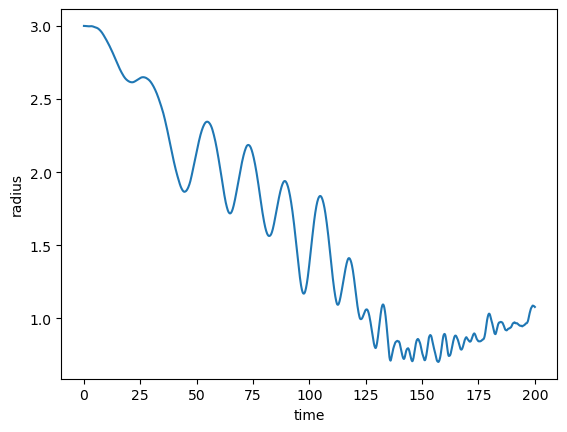

In [10]:
plt.plot(time, radius[0])
plt.ylabel('radius')
plt.xlabel('time')

In [11]:
pos_BH_1 = positions[0, :, :]
pos_BH_2 = positions[1, :, :]

BH_distance = 0.0
for i in range(3): BH_distance += (pos_BH_1[:, i] - pos_BH_2[:, i])**2

BH_distance = np.sqrt(BH_distance)

Text(0.5, 0, 'time')

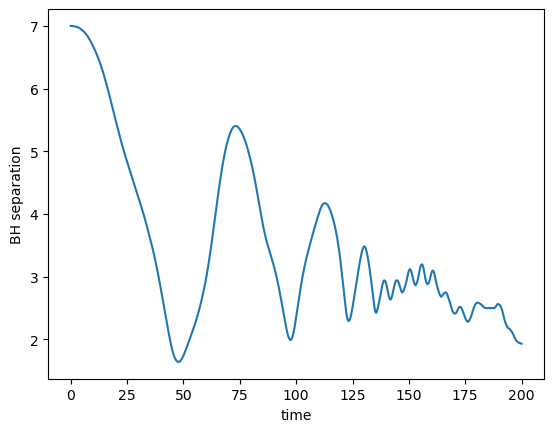

In [12]:
plt.plot(time, BH_distance)
plt.ylabel('BH separation')
plt.xlabel('time')

Text(0.5, 0, 'time')

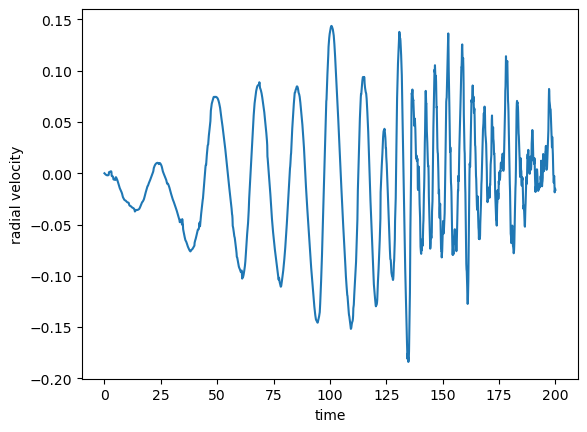

In [13]:
radial_v = []
for i in range(n_particles): radial_v.append((positions[i, :, 0]*velocities[i, :, 0] + positions[i, :, 1]*velocities[i, :, 1] + positions[i, :, 2]*velocities[i, :, 2])/radius[i, :])
radial_v = np.array(radial_v)

plt.plot(time, radial_v[0])
plt.ylabel('radial velocity')
plt.xlabel('time')

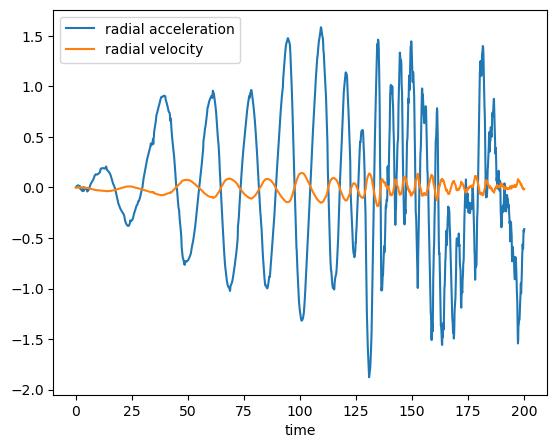

In [14]:
r_acc = np.gradient(radial_v)/np.gradient(time)

fig = plt.figure(figsize = (14, 5))

ax = fig.add_subplot(121)
ax.plot(time, r_acc[0, 0], label = 'radial acceleration')
ax.plot(time, radial_v[0], label = 'radial velocity')
ax.set(xlabel = 'time')
plt.legend()

In [15]:
gifname=outputname.replace('output_', '')
gifname=gifname.replace('txt', 'mp4')
print(gifname)

runs/25_8/H_2025-08-25_19-58-32.mp4


In [16]:
import matplotlib.animation as animation
from matplotlib.animation import FFMpegWriter

starting animation


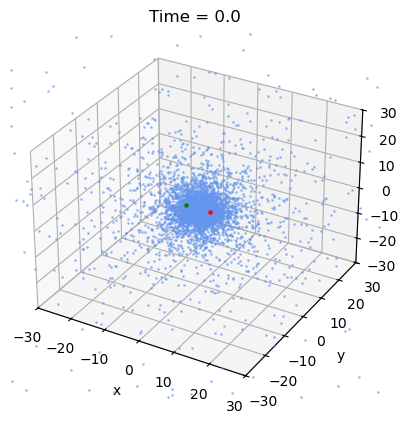

In [17]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d', computed_zorder=False)
ax.set_aspect('auto')
ax.set(xlim = [-30.0, 30.0], ylim = [-30.0, 30.0], zlim = [-30.0, 30.0], xlabel='x', ylabel='y', zlabel = 'z')

scatter_BH_1 = ax.scatter([positions[0, 0, 0]], [positions[0, 0, 1]], [positions[0, 0, 2]],
                           color='red', edgecolors='red', s=5, zorder=1)
scatter_BH_2 = ax.scatter([positions[1, 0, 0]], [positions[1, 0, 1]], [positions[1, 0, 2]],
                            color='green', edgecolors='green', s=5, zorder=1)
scatters, = ax.plot(positions[:, 0, 0], positions[:, 0, 1], positions[:, 0, 2], 'o', color='cornflowerblue', markersize = '1', alpha = 0.5, zorder=0)

print('starting animation')
  
def update(frame):
    scatters.set_data(positions[:, frame, 0], positions[:, frame, 1]) 
    scatters.set_3d_properties(positions[:, frame, 2])
    
    scatter_BH_1._offsets3d = ([positions[0, frame, 0]],
                           [positions[0, frame, 1]],
                           [positions[0, frame, 2]])

    scatter_BH_2._offsets3d = ([positions[1, frame, 0]],
                           [positions[1, frame, 1]],
                           [positions[1, frame, 2]])
    
    ax.set_title('Time = %.1f'%(time[frame]))

    return scatters, scatter_BH_1, scatter_BH_2
    
ani = animation.FuncAnimation(fig, update, snap_number, interval=16)

ani.save(gifname, writer = animation.FFMpegWriter(fps=60))

Assuming the BH to always have $z \simeq 0$, we can draw their 2d orbit.

In [18]:
gifname_2d = gifname.replace('H', '2D')

starting animation


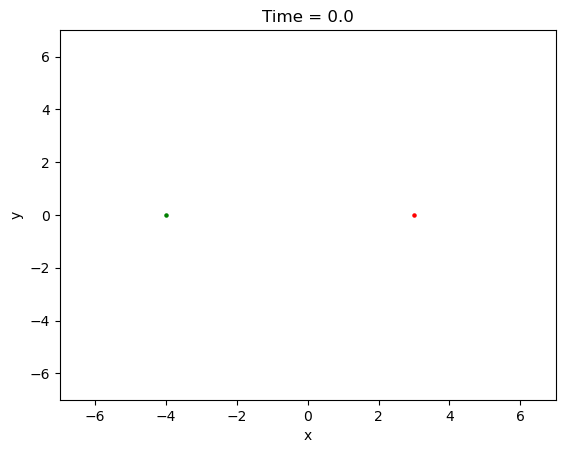

In [19]:
fig = plt.figure()
ax = fig.add_subplot()
ax.set_aspect('auto')
ax.set(xlim = [-7.0, 7.0], ylim = [-7.0, 7.0], xlabel='x', ylabel='y')

scatter_BH_1 = ax.scatter(positions[0, 0, 0], positions[0, 0, 1],
                           color='red', edgecolors='red', s=5)
scatter_BH_2 = ax.scatter(positions[1, 0, 0], positions[1, 0, 1],
                            color='green', edgecolors='green', s=5)

print('starting animation')
  
def update(frame):
    scatter_BH_1.set_offsets(positions[0, frame, :2])
    scatter_BH_2.set_offsets(positions[1, frame, :2])
    
    ax.set_title('Time = %.1f'%(time[frame]))

    return scatter_BH_1, scatter_BH_2
    
ani = animation.FuncAnimation(fig, update, snap_number, interval=16)

#ani.save(gifname, writer = 'ffmpeg')
ani.save(gifname_2d, writer = animation.FFMpegWriter(fps=60))

### BH CoM

In [20]:
def BH_CoM(BH_1, BH_2, M_1, M_2):
    com = (M_1*BH_1 + M_2*BH_2) / (M_1 + M_2)
    return com

def CoM_distance (obj_pos, com_pos = CoM):
    distance = com_pos - obj_pos
    return distance

NameError: name 'CoM' is not defined

In [ ]:
CoM = BH_CoM(pos_BH_1, pos_BH_2, mass[0], mass[1])

BH_1_com = CoM_distance(pos_BH_1, CoM)
BH_2_com = CoM_distance(pos_BH_2, CoM)

In [ ]:
gifname_com = gifname.replace('H', 'BH-CoM')

In [ ]:
fig = plt.figure()
ax = fig.add_subplot()
ax.set_aspect('auto')
ax.set(xlim = [-7.0, 7.0], ylim = [-7.0, 7.0], xlabel='x', ylabel='y')

scatter_BH_1 = ax.scatter(BH_1_com[0, 0], BH_1_com[0, 1], color='red', edgecolors='red', s=5)
scatter_BH_2 = ax.scatter(BH_2_com[0, 0], BH_2_com[0, 1], color='green', edgecolors='green', s=5)

print('starting animation')
  
def update(frame):
    scatter_BH_1.set_offsets(BH_1_com[frame, :2])
    scatter_BH_2.set_offsets(BH_2_com[frame, :2])
    
    ax.set_title('Time = %.1f'%(time[frame]))

    return scatter_BH_1, scatter_BH_2
    
ani = animation.FuncAnimation(fig, update, snap_number, interval=16)

#ani.save(gifname, writer = 'ffmpeg')
ani.save(gifname_com, writer = animation.FFMpegWriter(fps=60))

### Energy

In [ ]:
#Get the total energies from the log file, in the CM frame
def GetEnergy(filename, N):
    file_output = open(filename, "r")
    output = np.array(file_output.read().splitlines())
    
    idx = np.where(output == output[9])[0] #Find the row with T and U

    E = []
    K = []
    U = []
    t = []
    
    for i in idx:
        t.append(float(output[i+1].split()[0]))
        E.append(float(output[i + 1].split()[1]))
        K.append(float(output[i + 1].split()[2]))
        U.append(-float(output[i + 1].split()[3]))
        
    #K = (np.array(K) - K_CM) * M_sun / v_iu_cgs**2
    #U = np.array(U) * G_p * 
    #E = np.add(K, U)

    file_output.close()
    return t, E, K, U

In [ ]:
time_E, E, K, U = GetEnergy(logname, n_particles)

In [ ]:
    #----------Plot of the energy----------

plt.plot(time_E, E, label="Total energy in the CM frame")
plt.plot(time_E, K, label="Total kinetic energy in the CM frame")
plt.plot(time_E, U, label="Total potential energy in the CM frame")
plt.xlabel("t", fontsize = 14)
plt.ylabel("Energy", fontsize = 14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)
plt.show()

In [ ]:
virial_ratio = []
for t in range(len(time_E)):
    virial_ratio.append(2 * K[t] / ( - U[t]))

plt.plot(time_E, virial_ratio)
plt.hlines(1.0, 0, max(time_E), color = 'r')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('time_E')
plt.ylabel('virial ratio')
plt.ylim(0, 2)
plt.show()

In [ ]:
print(2 * K[0] / np.abs(U[0]))

## Check if density is Hernquist

In [ ]:
def compute_rho(radius):
    return M/(2*np.pi) * a/radius * 1/(radius+a)**3

M = 1
n = 5000
a = 1

In [ ]:
def count_particles(radius, r_min, r_max):
    return int(np.sum((radius > r_min) & (radius < r_max)))

def numerical_density(radius, n_check):
    grid = np.geomspace(min(radius), max(radius), n_check)
    rho = []
    grid_centres = []
    
    for i in range(n_check-1):
        dn = count_particles(radius, grid[i], grid[i+1]) 
        if dn > 1:
            grid_centres.append(float(grid[i+1]))
            dV = 4*np.pi/3 * (grid[i+1]**3 - grid_centres[len(grid_centres)-2]**3)
            rho.append( (M/n) * (dn/dV) )
    
    return rho, grid_centres

In [ ]:
if density_plot == True :
    folder = 'density_pics/'
    for i in tqdm(range(snap_number)):
        num_rho, rho_grid = numerical_density(radius_at_t[i], 500)
    
        analytical_rho = [compute_rho(rg) for rg in rho_grid]
        plt.scatter(rho_grid, num_rho, s = 3, label ='numerical')
        plt.plot(rho_grid, analytical_rho , c = 'r', label = 'analytical')
        plt.xlabel('radius')
        plt.ylabel('density')
        plt.xlim(1E-2, 1E4)
        plt.ylim(1E-14, 1E2)
        plt.legend()
        plt.loglog()
        plt.savefig(folder+str(i)+'.png', dpi=200)
        plt.close()

In [ ]:
#from moviepy import ImageSequenceClip

#clip = ImageSequenceClip('./img_SF_LF/', fps = 7)
#clip.write_videofile('movie_SF_LF.mp4')
#clip.close()